In [90]:
from prophet import Prophet
import pandas as pd
from matplotlib import pyplot as plt

In [91]:
sales_df = pd.read_csv('./dataset/stone_mountain_sales_2019_to_2024.csv')
sales_df = sales_df.head(68)
sales_df.rename(columns={'Month_End': 'ds', 'Sales_Count': 'y'}, inplace=True)

In [92]:
sales_df.tail()

,ds,y
63,2024-04-30,35
64,2024-05-31,41
65,2024-06-30,34
66,2024-07-31,50
67,2024-08-31,29


In [93]:
sales_df['ds'] = pd.to_datetime(sales_df['ds'])

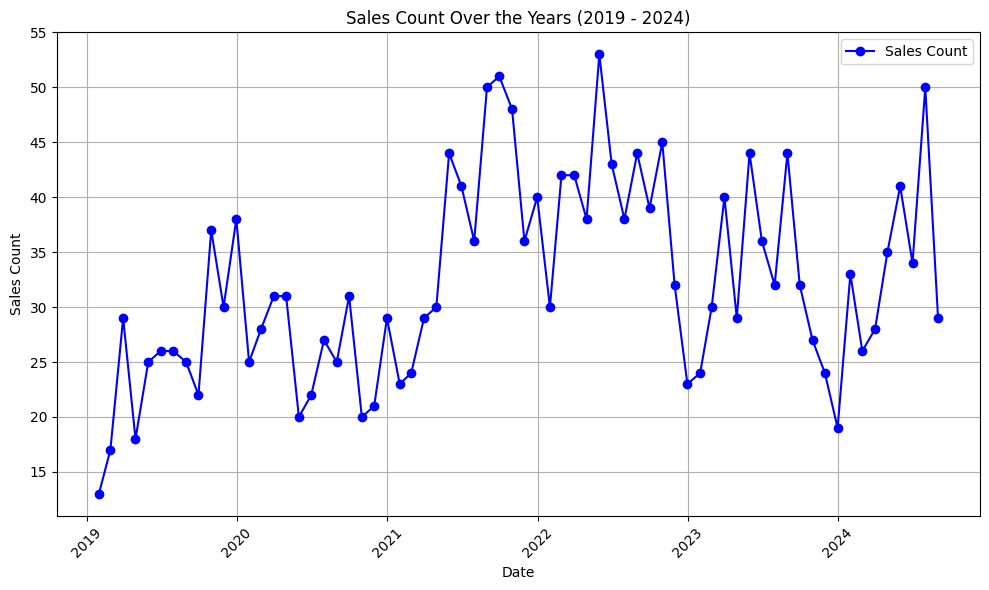

In [94]:
plt.figure(figsize=(10, 6))
plt.plot(sales_df['ds'], sales_df['y'], marker='o', linestyle='-', color='b', label='Sales Count')

plt.title('Sales Count Over the Years (2019 - 2024)')
plt.xlabel('Date')
plt.ylabel('Sales Count')
plt.grid(True)
plt.xticks(rotation=45)  
plt.tight_layout()       

plt.legend()
plt.show()

In [95]:
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    # changepoint_prior_scale=0.1,  # Higher sensitivity to trend changes
    # seasonality_prior_scale=10.0,  # Allow stronger influence from seasonal patterns
    #seasonality_mode='additive'  # Set seasonality mode to multiplicative
)
# model.add_seasonality(name='yearly', period=365.25, fourier_order=10)  
# model.add_seasonality(name='quarterly', period=91.25, fourier_order=5)

In [96]:
model.fit(sales_df)

16:28:04 - cmdstanpy - INFO - Chain [1] start processing
16:28:04 - cmdstanpy - INFO - Chain [1] done processing


In [97]:
future = model.make_future_dataframe(periods=12, freq='ME')
forecast = model.predict(future)

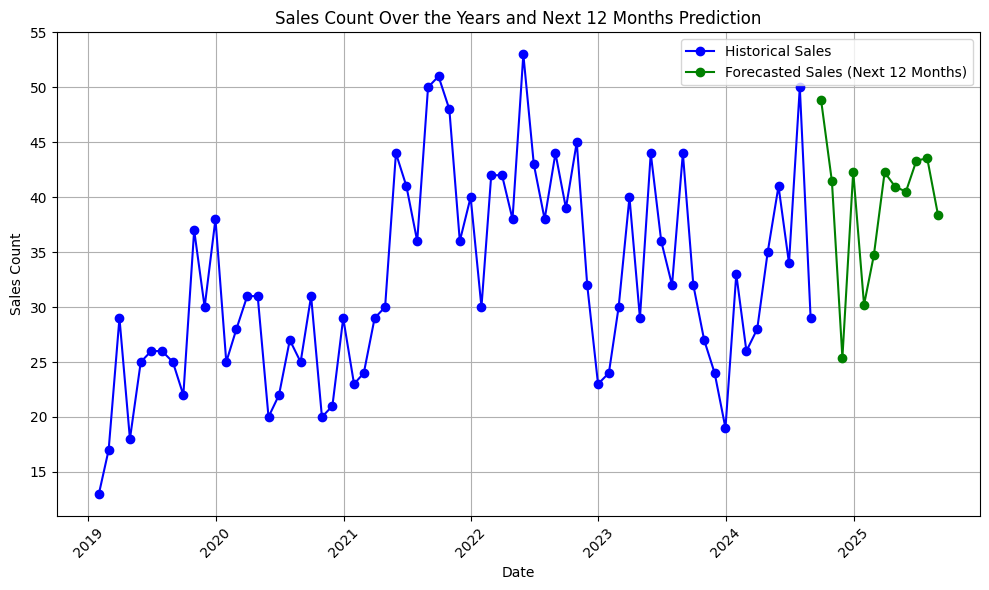

In [98]:
plt.figure(figsize=(10, 6))

plt.plot(sales_df['ds'], sales_df['y'], marker='o', linestyle='-', color='b', label='Historical Sales')

forecasted_data = forecast[['ds', 'yhat']].tail(12) 
plt.plot(forecasted_data['ds'], forecasted_data['yhat'], marker='o', linestyle='-', color='g', label='Forecasted Sales (Next 12 Months)')

plt.title('Sales Count Over the Years and Next 12 Months Prediction')
plt.xlabel('Date')
plt.ylabel('Sales Count')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.legend()
plt.show()

In [99]:
predicted_sales_df = forecast[['ds','yhat_lower']].tail(12)
predicted_sales_df.tail(12)

,ds,yhat_lower
68,2024-09-30,40.318378
69,2024-10-31,32.681778
70,2024-11-30,16.310599
71,2024-12-31,33.065050
72,2025-01-31,21.250457
73,2025-02-28,25.534679
74,2025-03-31,33.765720
75,2025-04-30,31.461527
76,2025-05-31,31.680365
77,2025-06-30,34.157453


In [100]:
predicted_sales_df = predicted_sales_df.tail(12)
predicted_sales_df['ds'] = pd.to_datetime(predicted_sales_df['ds'])

In [101]:
sales_df.rename(columns={'ds': 'date', 'y': 'sales_count'}, inplace=True)
sales_df

,date,sales_count
0,2019-01-31,13
1,2019-02-28,17
2,2019-03-31,29
3,2019-04-30,18
4,2019-05-31,25
...,...,...
63,2024-04-30,35
64,2024-05-31,41
65,2024-06-30,34
66,2024-07-31,50


In [102]:
predicted_sales_df.rename(columns={'ds': 'date', 'yhat_lower': 'sales_count'}, inplace=True)
predicted_sales_df['sales_count'] = predicted_sales_df['sales_count'].round().astype(int)
predicted_sales_df

,date,sales_count
68,2024-09-30,40
69,2024-10-31,33
70,2024-11-30,16
71,2024-12-31,33
72,2025-01-31,21
73,2025-02-28,26
74,2025-03-31,34
75,2025-04-30,31
76,2025-05-31,32
77,2025-06-30,34


In [103]:
sales_df['date'] = pd.to_datetime(sales_df['date'])
predicted_sales_df['date'] = pd.to_datetime(predicted_sales_df['date'])

In [104]:
merged_df = pd.concat([sales_df, predicted_sales_df], ignore_index=True)

In [105]:
merged_df.tail(15)

,date,sales_count
65,2024-06-30,34
66,2024-07-31,50
67,2024-08-31,29
68,2024-09-30,40
69,2024-10-31,33
70,2024-11-30,16
71,2024-12-31,33
72,2025-01-31,21
73,2025-02-28,26
74,2025-03-31,34


In [106]:
merged_df.to_csv('./predicted_dataset/sale_predicted_stone_mountain.csv',index=False)